# Introduction

A brain tumor is an abnormal growth of cells within the brain. Due to the rigid structure of the skull, any abnormal growth can increase intracranial pressure and potentially lead to severe neurological damage. Early detection and accurate classification of brain tumors are critical for selecting appropriate treatment strategies and improving patient outcomes.

In this project, we develop a deep learning-based computer vision model to automatically classify brain MRI images into clinically relevant categories. Automating this process can assist radiologists by providing faster and more consistent preliminary assessments.

<div align="center">
    <img src="https://cdn-images-1.medium.com/v2/resize:fit:800/1*f1sodi17fNcObGBmIKgGGQ.gif" width=400>
</div>

The dataset consists of 7,200 human brain MRI images categorized into four classes:

- **Glioma** – tumors arising from glial cells, often aggressive
- **Meningioma** – tumors originating in the meninges, typically slower growing
- **Pituitary** – tumors affecting the pituitary gland
- **No tumor** – healthy brain scans

### Dataset Structure
```
Training/
    glioma/        (1400 images)
    meningioma/    (1400 images)
    pituitary/     (1400 images)
    notumor/       (1400 images)

Testing/
    glioma/        (400 images)
    meningioma/    (400 images)
    pituitary/     (400 images)
    notumor/       (400 images)
```

### Approach
- Data preprocessing and augmentation to improve generalization
- Transfer learning using a pretrained CNN backbone (Xception)
- Fine-tuning with class balancing and regularization
- Evaluation using accuracy, precision, recall, and confusion matrix

# 1. Import Libraries

In [1]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import shutil
# import warnings
# warnings.filterwarnings("ignore")

In [2]:
!pip install -q --upgrade tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 3.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 107.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 23.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-cloud-videointelligence 2.18.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
google-cloud-vision 3.12.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<7.0.0,>=3.20.2, but you have pr

# 2. Exploratory Data Analysis

In [3]:
data_dir = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"
train_dir = data_dir + "/Training"
test_dir = data_dir + "/Testing"

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

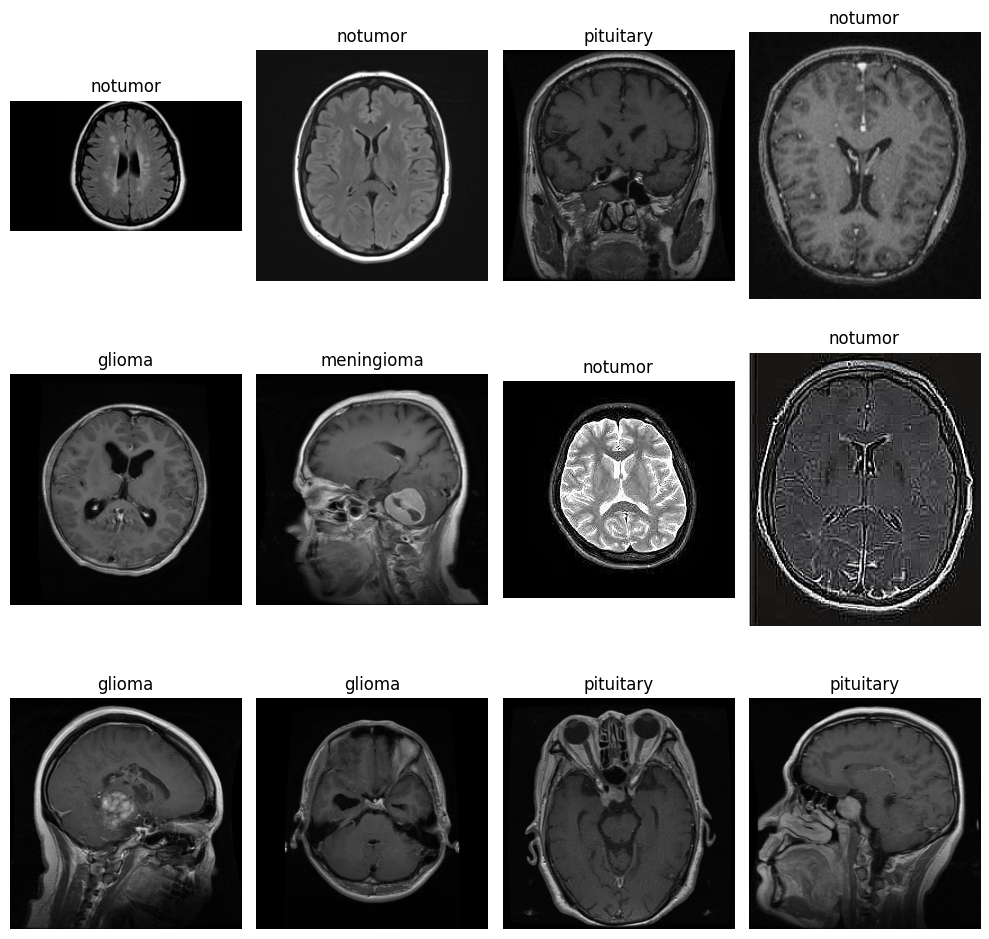

In [4]:
plt.figure(figsize=(10, 10))

for i in range(12):
    class_name = random.choice(class_names)
    img_path = os.path.join(train_dir, class_name, random.choice(os.listdir(os.path.join(train_dir, class_name))))
    img = cv2.imread(img_path)

    plt.subplot(3, 4, i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(class_name)
    plt.axis("off")
    
plt.tight_layout()
plt.show()

### 2.1 Class Distribution

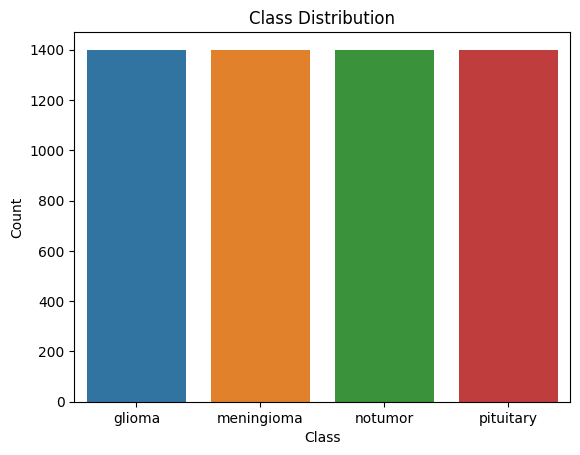

In [5]:
class_count = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    count = len(os.listdir(class_path))
    class_count.append((class_name, count))

class_df = pd.DataFrame(class_count, columns=["Class", "Count"])

sns.barplot(data=class_df, x="Class", y="Count", hue="Class")
plt.title("Class Distribution")
plt.show()

### 2.2 Image Sizes Range

In [6]:
widths = []
heights = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for img_name in os.listdir(class_path)[:100]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        h, w, _ = img.shape
        widths.append(w) if w not in widths else None
        heights.append(h) if h not in heights else None

print("Width Range:", min(widths), "to", max(widths))
print("Height Range:", min(heights), "to", max(heights))

Width Range: 150 to 1000
Height Range: 192 to 993


### 2.3 Classwise Pixel Intensity Distribution

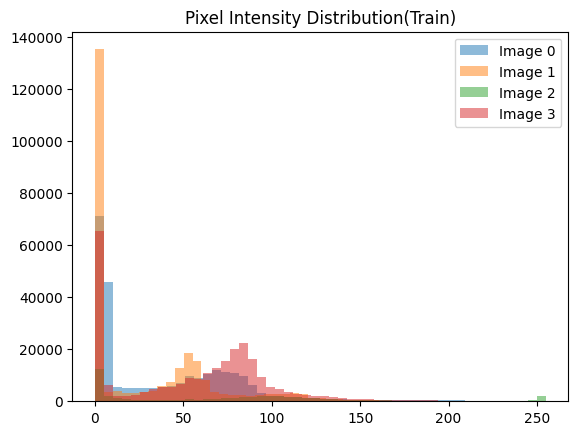

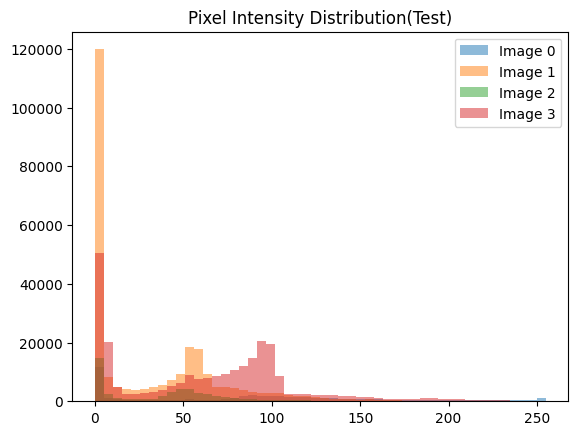

In [7]:
sample_images_train = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img = cv2.imread(os.path.join(class_path, img_name), cv2.IMREAD_GRAYSCALE)
    sample_images_train.append(img)

for i, image in enumerate(sample_images_train):
    plt.hist(image.ravel(), bins=50, alpha=0.5, label=f"Image {i}")

plt.legend()
plt.title("Pixel Intensity Distribution(Train)")
plt.show()

sample_images_test = []
for class_name in class_names:
    class_path = os.path.join(test_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img = cv2.imread(os.path.join(class_path, img_name), cv2.IMREAD_GRAYSCALE)
    sample_images_test.append(img)

for i, image in enumerate(sample_images_test):
    plt.hist(image.ravel(), bins=50, alpha=0.5, label=f"Image {i}")

plt.legend()
plt.title("Pixel Intensity Distribution(Test)")
plt.show()

We need normalization, because:
- Data is heavily skewed toward dark values.
- Different images have different distributions.

# 3. Load the Dataset

In [8]:
import tensorflow as tf

In [9]:
gpus = tf.config.list_physical_devices("GPU")

print("GPUs available:", gpus)

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

strategy = tf.distribute.MirroredStrategy()

print("Number of GPUs used:", strategy.num_replicas_in_sync)

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of GPUs used: 2


In [10]:
from sklearn.model_selection import train_test_split
def move_data_to_work(train_dir, test_dir, train_out, test_out, test_size=1600/7200):
    filepaths = []
    labels = []

    # Collect all data from both directories
    for base_dir in [train_dir, test_dir]:
        for class_name in os.listdir(base_dir):
            class_path = os.path.join(base_dir, class_name)

            if not os.path.isdir(class_path):
                continue

            for fname in os.listdir(class_path):
                fpath = os.path.join(class_path, fname)

                if os.path.isfile(fpath):
                    filepaths.append(fpath)
                    labels.append(class_name)

    # Stratified split
    train_paths, test_paths, train_labels, test_labels = train_test_split(filepaths, labels, test_size=test_size, stratify=labels, random_state=42)

    # Helper to copy files
    def copy_files(paths, labels, output_dir, prefix):
        for path, label in zip(paths, labels):
            class_dir = os.path.join(output_dir, label)
            os.makedirs(class_dir, exist_ok=True)
            fname = os.path.basename(path)
            new_name = prefix + fname
            dst_path = os.path.join(class_dir, new_name)
            shutil.copy2(path, dst_path)

    # Copy to output directories
    copy_files(train_paths, train_labels, train_out, prefix="train_")
    copy_files(test_paths, test_labels, test_out, prefix="test_")

    print(f"Done! Train: {len(train_paths)} | Test: {len(test_paths)}")

In [11]:
%%time
train_out = "/kaggle/working/train"
test_out = "/kaggle/working/test"
move_data_to_work(train_dir, test_dir, train_out, test_out)

Done! Train: 5600 | Test: 1600
CPU times: user 1.03 s, sys: 1.92 s, total: 2.96 s
Wall time: 1min 4s


### 3.1 Data Generators

In [12]:
import keras

IMG_SIZE = (299, 299)
BATCH_SIZE = 64

train_ds = keras.utils.image_dataset_from_directory(
    train_out,
    validation_split=0.18,
    subset="training",
    label_mode='categorical',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    pad_to_aspect_ratio=True
)

val_ds = keras.utils.image_dataset_from_directory(
    train_out,
    validation_split=0.18,
    subset="validation",
    label_mode='categorical',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    pad_to_aspect_ratio=True
)

test_ds = keras.utils.image_dataset_from_directory(
    test_out,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pad_to_aspect_ratio=True
)

train_eval_ds = keras.utils.image_dataset_from_directory(
    train_out,
    validation_split=0.18,
    subset="training",
    label_mode='categorical',
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pad_to_aspect_ratio=True
)

Found 5600 files belonging to 4 classes.
Using 4592 files for training.
Found 5600 files belonging to 4 classes.
Using 1008 files for validation.
Found 1600 files belonging to 4 classes.
Found 5600 files belonging to 4 classes.
Using 4592 files for training.


### 3.2 Augmentation

In [13]:
from keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2)
])

### 3.3 Preprocess & Augment

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

# Training: cache raw → preprocess → cache preprocessed → augment fresh each epoch → shuffle → prefetch → model
train_data = (train_ds
    .cache()
    .shuffle(2000)
    .prefetch(AUTOTUNE)
)

# Validation: preprocess → cache → prefetch → model
val_data = val_ds.cache().prefetch(AUTOTUNE)

# Testing: preprocess → prefetch → model
test_data = test_ds.prefetch(AUTOTUNE)

# Training set without any augmentations for the final evaluation
train_eval_data = train_eval_ds.prefetch(AUTOTUNE)

# 4. Model Training

In [15]:
# Set the Mixed-float16 poliy for the model training
keras.mixed_precision.set_global_policy("mixed_float16")
print(keras.mixed_precision.global_policy())

<DTypePolicy "mixed_float16">


In [16]:
with strategy.scope():
    base_model = keras.applications.Xception(include_top=False, weights="imagenet", input_shape=(299, 299, 3))
    base_model.trainable = False

    inputs = layers.Input(shape=(299, 299, 3))
    x = data_augmentation(inputs)
    x = layers.Rescaling(scale=1./127.5, offset=-1, name="xception_preprocess")(x)
    x = base_model(x, training=False)
    gap = layers.GlobalAveragePooling2D()(x)
    gmp = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([gap, gmp])
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.36)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.24)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    outputs = layers.Dense(4, activation='softmax', dtype='float32')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 299, 299,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception_preprocess │ (None, 299, 299,  │          0 │ sequential[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ xception            │ (None, 10, 10,    │ 20,861,480 │ xception_preproc… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ xception[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 2048)      │          0 │ xception[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4096)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4096)      │     16,384 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      4,128 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │        132 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 21,965,388 (83.79 MB)

 Trainable params: 1,094,948 (4.18 MB)

 Non-trainable params: 20,870,440 (79.61 MB)

### A new metric: `TumorRecall` for 2 difficult classes Glioma and Meningioma

In [17]:
@keras.saving.register_keras_serializable()
class TumorRecall(tf.keras.metrics.Metric):
    def __init__(self, name='tumor_recall', **kwargs):
        super().__init__(name=name, **kwargs)
        # Glioma
        self.tp_glioma = self.add_weight(
            name="tp_glioma",
            initializer="zeros"
        )
        self.fn_glioma = self.add_weight(
            name="fn_glioma",
            initializer="zeros"
        )
        # Meningioma
        self.tp_meningioma = self.add_weight(
            name="tp_meningioma",
            initializer="zeros"
        )
        self.fn_meningioma = self.add_weight(
            name="fn_meningioma",
            initializer="zeros"
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convert one-hot y_true -> integer class labels
        y_true = tf.argmax(y_true, axis=-1)
        # Convert softmax probabilities -> predicted class
        y_pred = tf.argmax(y_pred, axis=-1)
        # -------------------------
        # Glioma (class 0)
        # -------------------------
        true_glioma = tf.equal(y_true, 0)
        pred_glioma = tf.equal(y_pred, 0)
        
        tp_glioma = tf.reduce_sum(
            tf.cast(true_glioma & pred_glioma, tf.float32)
        )
        fn_glioma = tf.reduce_sum(
            tf.cast(true_glioma & ~pred_glioma, tf.float32)
        )

        # -------------------------
        # Meningioma (class 1)
        # -------------------------
        true_meningioma = tf.equal(y_true, 1)
        pred_meningioma = tf.equal(y_pred, 1)

        tp_meningioma = tf.reduce_sum(
            tf.cast(true_meningioma & pred_meningioma, tf.float32)
        )
        fn_meningioma = tf.reduce_sum(
            tf.cast(true_meningioma & ~pred_meningioma, tf.float32)
        )

        # Accumulate over batches
        self.tp_glioma.assign_add(tp_glioma)
        self.fn_glioma.assign_add(fn_glioma)

        self.tp_meningioma.assign_add(tp_meningioma)
        self.fn_meningioma.assign_add(fn_meningioma)

    def result(self):

        glioma_recall = (
            self.tp_glioma /
            (self.tp_glioma + self.fn_glioma + tf.keras.backend.epsilon())
        )

        meningioma_recall = (
            self.tp_meningioma /
            (self.tp_meningioma + self.fn_meningioma + tf.keras.backend.epsilon())
        )

        return (glioma_recall + meningioma_recall) / 2.0

    def reset_state(self):
        self.tp_glioma.assign(0.0)
        self.fn_glioma.assign(0.0)
        self.tp_meningioma.assign(0.0)
        self.fn_meningioma.assign(0.0)

## 4.1 Feature Extraction

In [18]:
%%time
# Compile and fit the Model
with strategy.scope():
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=[
            tf.keras.metrics.CategoricalAccuracy(name='accuracy_pre'),
            tf.keras.metrics.Precision(name='precision_pre'),
            tf.keras.metrics.Recall(name='recall_pre'),
            tf.keras.metrics.F1Score(name='f1score_pre', average='micro'),
            tf.keras.metrics.Recall(class_id=0, name='recall_class_0_pre'),
            tf.keras.metrics.Recall(class_id=1, name='recall_class_1_pre'),
            tf.keras.metrics.Recall(class_id=2, name='recall_class_2_pre'),
            tf.keras.metrics.Recall(class_id=3, name='recall_class_3_pre'),
            TumorRecall(name='tumor_recall_pre')
        ])

earlystop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=5,
    restore_best_weights=True,
    min_delta=0.005
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    mode='min',
    save_best_only=True
)

history = model.fit(train_data, epochs=10, validation_data=val_data, callbacks=[earlystop, checkpoint], shuffle=False)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

## 4.2 Fine-Tuning

In [19]:
%%time
for layer in base_model.layers[-40:]:
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

with strategy.scope():
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=4e-5, weight_decay=1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=[
            tf.keras.metrics.CategoricalAccuracy(name='accuracy_fine'),
            tf.keras.metrics.Precision(name='precision_fine'),
            tf.keras.metrics.Recall(name='recall_fine'),
            tf.keras.metrics.F1Score(name='f1score_fine', average='micro'),
            tf.keras.metrics.Recall(class_id=0, name='recall_class_0_fine'),
            tf.keras.metrics.Recall(class_id=1, name='recall_class_1_fine'),
            tf.keras.metrics.Recall(class_id=2, name='recall_class_2_fine'),
            tf.keras.metrics.Recall(class_id=3, name='recall_class_3_fine'),
            TumorRecall(name='tumor_recall_fine')
        ])

earlystop = tf.keras.callbacks.EarlyStopping(
    monitor='val_tumor_recall_fine',
    mode='max',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_tumor_recall_fine',
    mode='max',
    save_best_only=True
)
class_weight_dict = {
    0: 1.5,   # glioma
    1: 2.4,   # meningioma — this is actual bottleneck
    2: 0.8,   # notumor — (very easy)
    3: 1.0    # pituitary — perfect, no help needed
}

history_fine = model.fit(train_data, class_weight=class_weight_dict, epochs=30, validation_data=val_data, callbacks=[earlystop, checkpoint, lr_schedule], shuffle=False)

Epoch 1/30
INFO:tensorflow:Collective all_reduce tensors: 37 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
72/72 ━━━━━━━━━━━━━━━━━━━━ 67s 591ms/step - accuracy_fine: 0.8924 - f1score_fine: 0.8924 - loss: 0.7124 - precision_fine: 0.9186 - recall_class_0_fine: 0.8310 - recall_class_1_fine: 0.8000 - recall_class_2_fine: 0.9230 - recall_class_3_fine: 0.8888 - recall_fine: 0.8604 - tumor_recall_fine: 0.8511 - val_accuracy_fine: 0.9167 - val_f1score_fine: 0.9167 - val_loss: 0.4249 - val_precision_fine: 0.9335 - val_recall_class_0_fine: 0.8803 - val_recall_class_1_fine: 0.8039 - val_recall_class_2_fine: 0.9222 - val_recall_class_3_fine: 0.9598 - val_recall_fine: 0.8919 - val_tumor_recall_fine: 0.8762 - learning_rate: 4.0000e-05
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 24s 332ms/step - accuracy_fine: 0.9153 - f1score_fine: 0.9153 - loss: 0.6140 - precision_fine: 0.9328 - recall_class_0_fine: 0.8619 - recall_class_1_fine: 0.8900 - re

## 4.3 Learning Curves

In [20]:
history_fine.history.keys()

dict_keys(['accuracy_fine', 'f1score_fine', 'loss', 'precision_fine', 'recall_class_0_fine', 'recall_class_1_fine', 'recall_class_2_fine', 'recall_class_3_fine', 'recall_fine', 'tumor_recall_fine', 'val_accuracy_fine', 'val_f1score_fine', 'val_loss', 'val_precision_fine', 'val_recall_class_0_fine', 'val_recall_class_1_fine', 'val_recall_class_2_fine', 'val_recall_class_3_fine', 'val_recall_fine', 'val_tumor_recall_fine', 'learning_rate'])

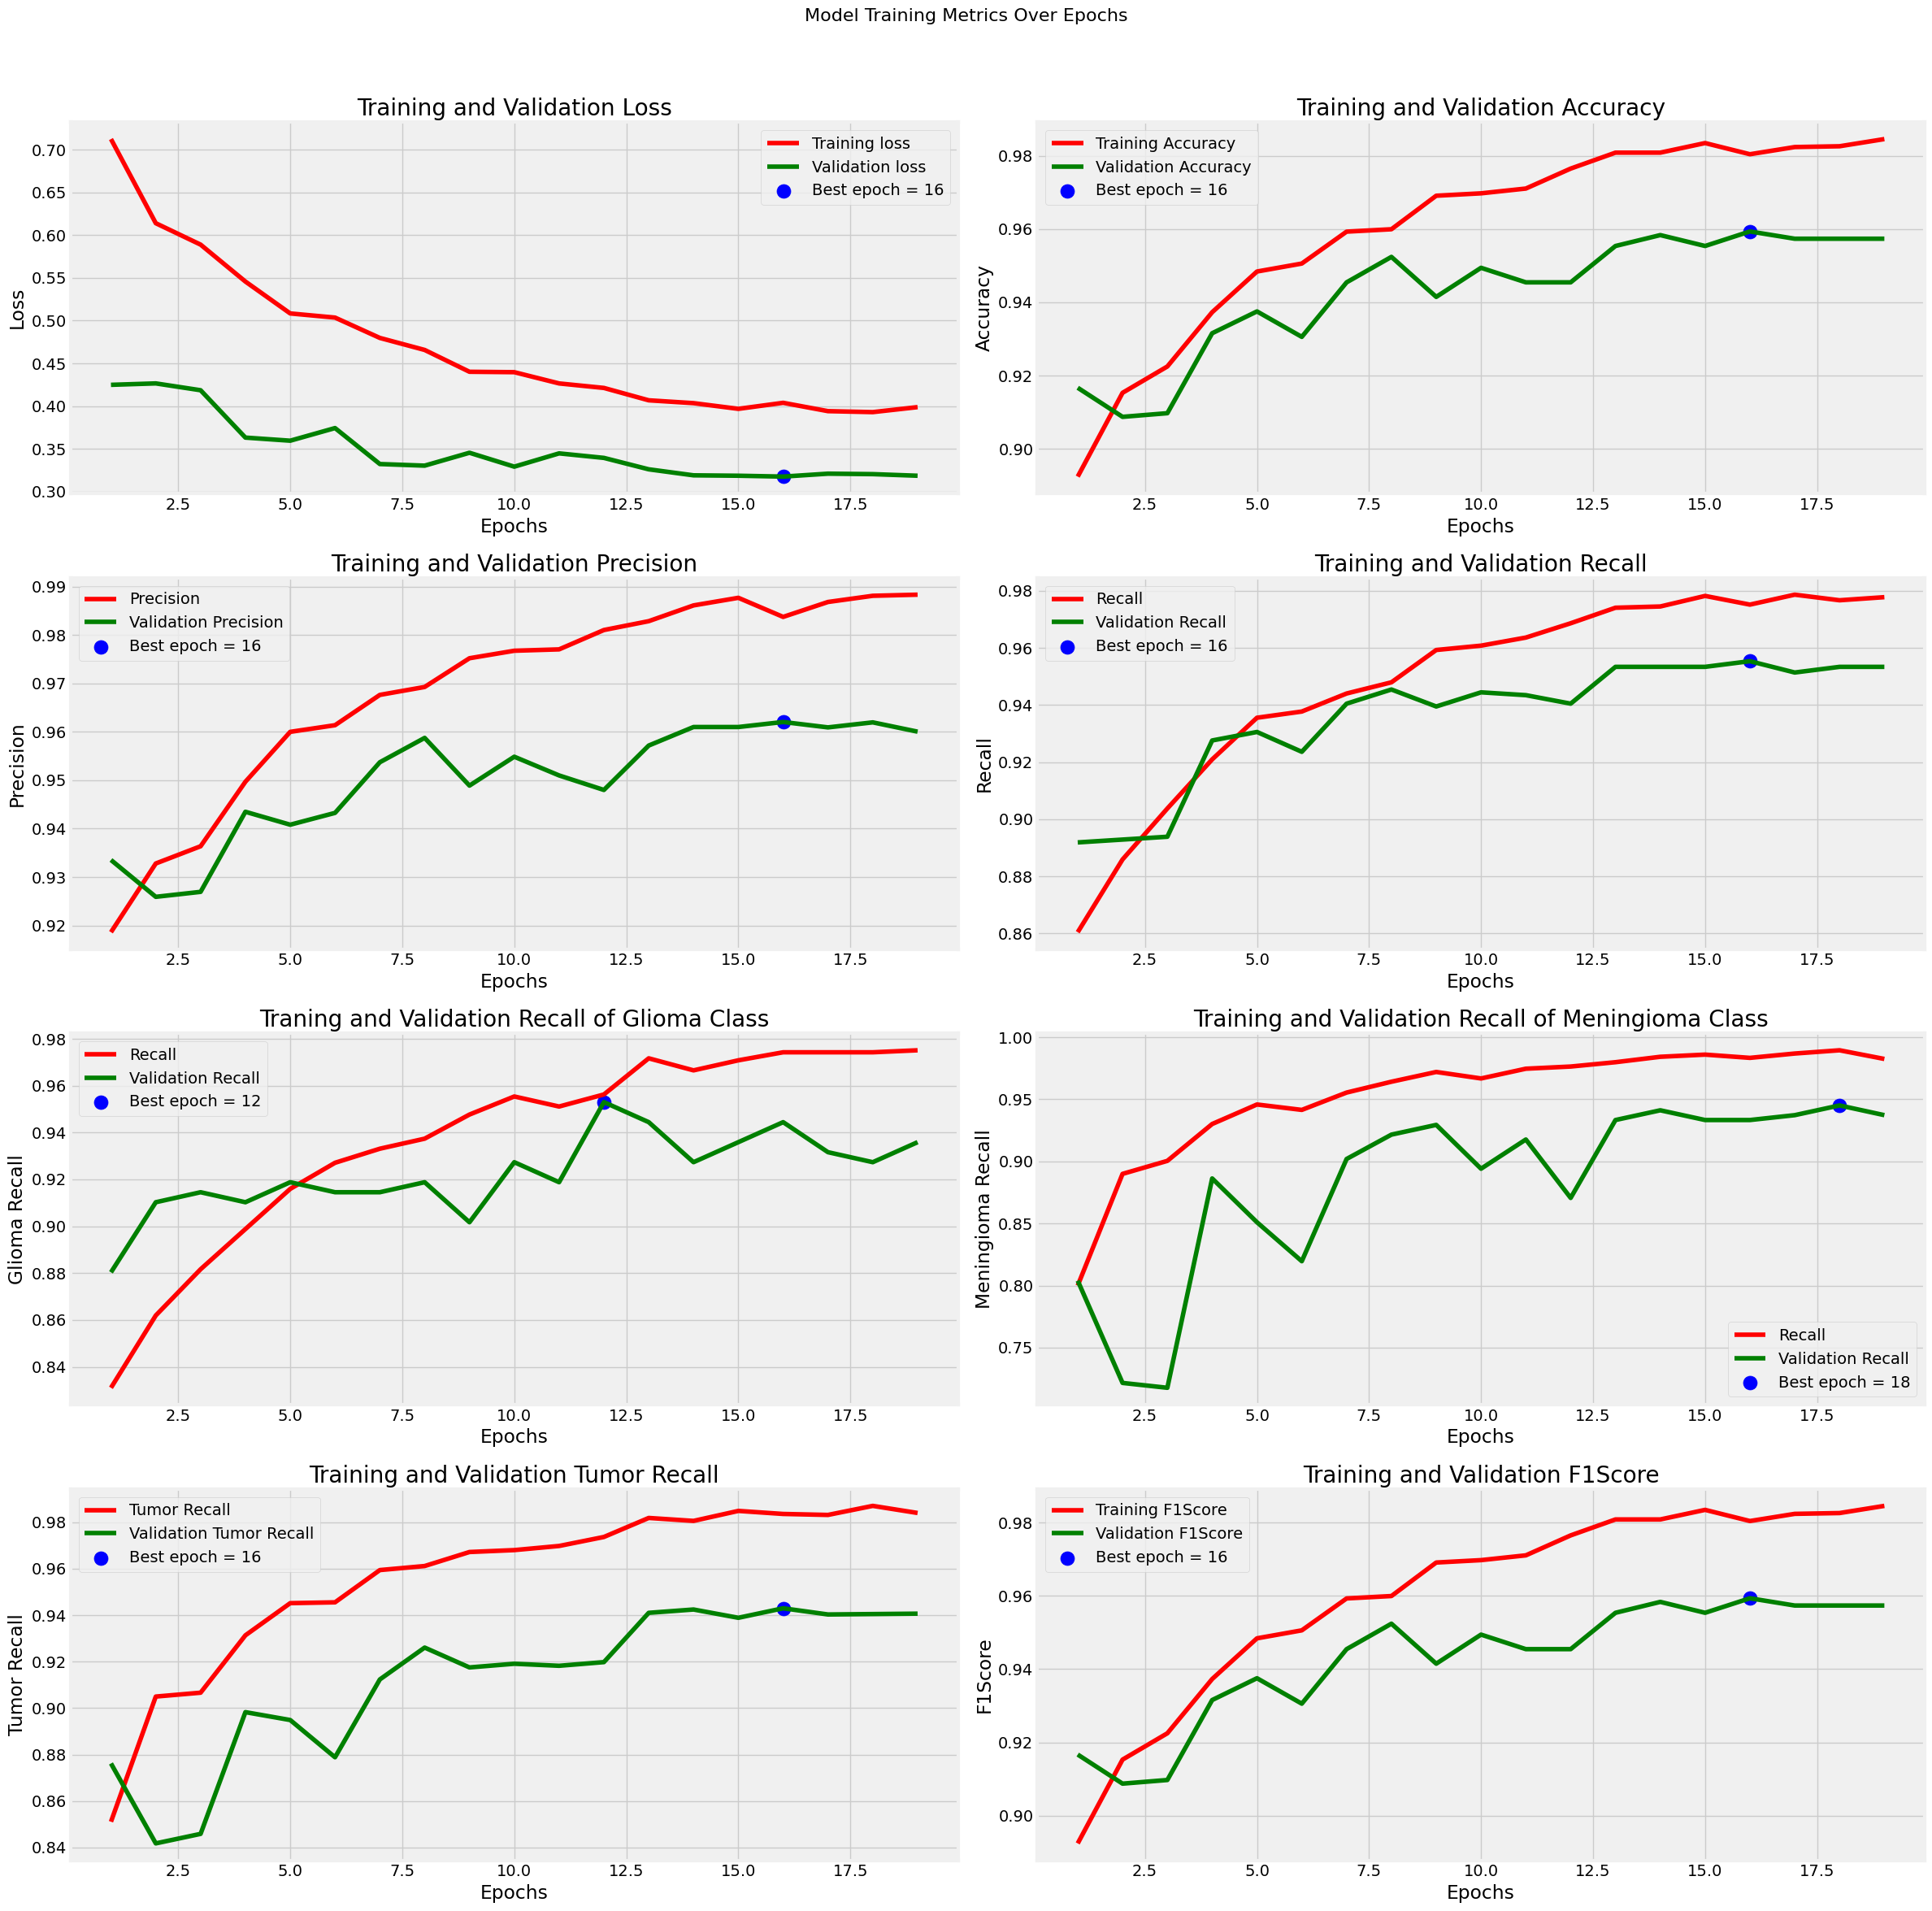

In [21]:
tr_acc = history_fine.history['accuracy_fine']
tr_loss = history_fine.history['loss']
tr_per = history_fine.history['precision_fine']
tr_recall = history_fine.history['recall_fine']
tr_recall_class_0 = history_fine.history['recall_class_0_fine']
tr_recall_class_1 = history_fine.history['recall_class_1_fine']
tr_tumor_recall_fine = history_fine.history['tumor_recall_fine']
tr_f1score_fine = history_fine.history['f1score_fine']
val_acc = history_fine.history['val_accuracy_fine']
val_loss = history_fine.history['val_loss']
val_per = history_fine.history['val_precision_fine']
val_recall = history_fine.history['val_recall_fine']
val_recall_class_0 = history_fine.history['val_recall_class_0_fine']
val_recall_class_1 = history_fine.history['val_recall_class_1_fine']
val_tumor_recall_fine = history_fine.history['val_tumor_recall_fine']
val_f1score_fine = history_fine.history['val_f1score_fine']

def get_best(values, mode='max'):
    if mode == 'max':
        idx = np.argmax(values)
    else:
        idx = np.argmin(values)
    return idx, values[idx]

index_loss, val_lowest = get_best(val_loss, 'min')
index_acc, acc_highest = get_best(val_acc, 'max')
index_precision, per_highest = get_best(val_per, 'max')
index_recall, recall_highest = get_best(val_recall, 'max')
index_recall_class_0, recall_class_0_highest = get_best(val_recall_class_0, 'max')
index_recall_class_1, recall_class_1_highest = get_best(val_recall_class_1, 'max')
index_tumor_recall, tumor_recall_highest = get_best(val_tumor_recall_fine, 'max')
index_f1score, f1score_highest = get_best(val_f1score_fine, 'max')

Epochs = [i + 1 for i in range(len(tr_acc))]
loss_label = f'Best epoch = {str(index_loss + 1)}'
acc_label = f'Best epoch = {str(index_acc + 1)}'
per_label = f'Best epoch = {str(index_precision + 1)}'
recall_label = f'Best epoch = {str(index_recall + 1)}'
recall_class_0_label = f'Best epoch = {str(index_recall_class_0 + 1)}'
recall_class_1_label = f'Best epoch = {str(index_recall_class_1 + 1)}'
tumor_recall_label = f'Best epoch = {str(index_tumor_recall + 1)}'
f1score_label = f'Best epoch = {str(index_f1score + 1)}'


plt.figure(figsize=(24, 24))
plt.style.use('fivethirtyeight')


plt.subplot(4, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label='Training loss')
plt.plot(Epochs, val_loss, 'g', label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='blue', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(4, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label='Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='blue', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(4, 2, 3)
plt.plot(Epochs, tr_per, 'r', label='Precision')
plt.plot(Epochs, val_per, 'g', label='Validation Precision')
plt.scatter(index_precision + 1, per_highest, s=150, c='blue', label=per_label)
plt.title('Training and Validation Precision')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)

plt.subplot(4, 2, 4)
plt.plot(Epochs, tr_recall, 'r', label='Recall')
plt.plot(Epochs, val_recall, 'g', label='Validation Recall')
plt.scatter(index_recall + 1, recall_highest, s=150, c='blue', label=recall_label)
plt.title('Training and Validation Recall')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)

plt.subplot(4, 2, 5)
plt.plot(Epochs, tr_recall_class_0, 'r', label='Recall')
plt.plot(Epochs, val_recall_class_0, 'g', label='Validation Recall')
plt.scatter(index_recall_class_0 + 1, recall_class_0_highest, s=150, c='blue', label=recall_class_0_label)
plt.title('Traning and Validation Recall of Glioma Class')
plt.xlabel('Epochs')
plt.ylabel('Glioma Recall')
plt.legend()
plt.grid(True)

plt.subplot(4, 2, 6)
plt.plot(Epochs, tr_recall_class_1, 'r', label='Recall')
plt.plot(Epochs, val_recall_class_1, 'g', label='Validation Recall')
plt.scatter(index_recall_class_1 + 1, recall_class_1_highest, s=150, c='blue', label=recall_class_1_label)
plt.title('Training and Validation Recall of Meningioma Class')
plt.xlabel('Epochs')
plt.ylabel('Meningioma Recall')
plt.legend()
plt.grid(True)

plt.subplot(4, 2, 7)
plt.plot(Epochs, tr_tumor_recall_fine, 'r', label='Tumor Recall')
plt.plot(Epochs, val_tumor_recall_fine, 'g', label='Validation Tumor Recall')
plt.scatter(index_tumor_recall + 1, tumor_recall_highest, s=150, c='blue', label=tumor_recall_label)
plt.title('Training and Validation Tumor Recall')
plt.xlabel('Epochs')
plt.ylabel('Tumor Recall')
plt.legend()
plt.grid(True)

plt.subplot(4, 2, 8)
plt.plot(Epochs, tr_f1score_fine, 'r', label='Training F1Score')
plt.plot(Epochs, val_f1score_fine, 'g', label='Validation F1Score')
plt.scatter(index_f1score + 1, f1score_highest, s=150, c='blue', label=f1score_label)
plt.title('Training and Validation F1Score')
plt.xlabel('Epochs')
plt.ylabel('F1Score')
plt.legend()
plt.grid(True)

plt.suptitle('Model Training Metrics Over Epochs', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 5. Evaluation

### 5.1 Evaluation Metrics for all sets

In [22]:
with strategy.scope():
    final_model = keras.models.load_model(
        "/kaggle/working/best_model.keras",
        custom_objects={'TumorRecall': TumorRecall}
    )

In [23]:
train_score = final_model.evaluate(train_eval_data, verbose=1)
valid_score = final_model.evaluate(val_data, verbose=1)
test_score = final_model.evaluate(test_data, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print(f"Combined Recall of 2 most difficult classes: {train_score[-1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print(f"Combined Recall of 2 most difficult classes: {valid_score[-1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")
print(f"Combined Recall of 2 most difficult classes: {test_score[-1]*100:.2f}%")

72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 232ms/step - accuracy_fine: 0.9811 - f1score_fine: 0.9811 - loss: 0.2627 - precision_fine: 0.9834 - recall_class_0_fine: 0.9793 - recall_class_1_fine: 0.9743 - recall_class_2_fine: 0.9821 - recall_class_3_fine: 0.9796 - recall_fine: 0.9787 - tumor_recall_fine: 0.9796
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 226ms/step - accuracy_fine: 0.9593 - f1score_fine: 0.9593 - loss: 0.3164 - precision_fine: 0.9629 - recall_class_0_fine: 0.9444 - recall_class_1_fine: 0.9294 - recall_class_2_fine: 0.9556 - recall_class_3_fine: 0.9839 - recall_fine: 0.9534 - tumor_recall_fine: 0.9430
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 239ms/step - accuracy_fine: 0.9638 - f1score_fine: 0.9637 - loss: 0.2923 - precision_fine: 0.9702 - recall_class_0_fine: 0.9500 - recall_class_1_fine: 0.9350 - recall_class_2_fine: 0.9625 - recall_class_3_fine: 0.9825 - recall_fine: 0.9575 - tumor_recall_fine: 0.9488
Train Loss: 0.2627
Train Accuracy: 98.11%
Combined Recall of 2 most difficult classes: 97.96%
-----------

### 5.2 Confusion Matrix

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step


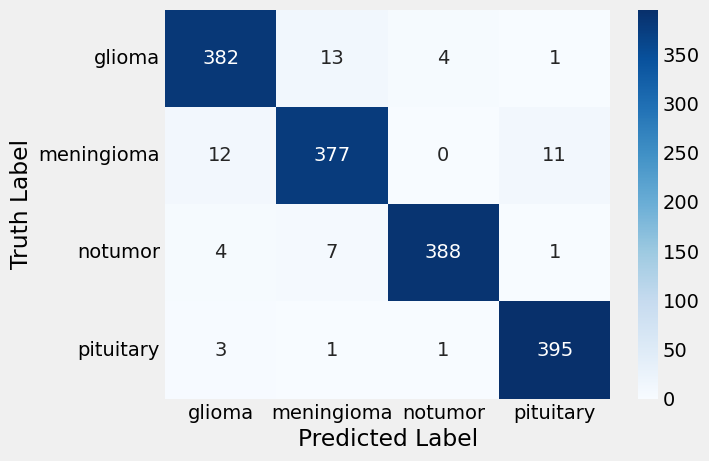

In [25]:
true_labels = np.concatenate([y.numpy() for x, y in test_data], axis=0)
true_labels = np.argmax(true_labels, axis=1)
preds = final_model.predict(test_data)
y_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(true_labels, y_pred)
labels = class_names
sns.heatmap(
    cm,
    annot=True,
    fmt='d', #forces integer format
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

### 5.3 Classification Report

In [26]:
clr = classification_report(true_labels, y_pred, target_names=class_names)
print(clr)

              precision    recall  f1-score   support

      glioma       0.95      0.95      0.95       400
  meningioma       0.95      0.94      0.94       400
     notumor       0.99      0.97      0.98       400
   pituitary       0.97      0.99      0.98       400

    accuracy                           0.96      1600
   macro avg       0.96      0.96      0.96      1600
weighted avg       0.96      0.96      0.96      1600



# 6. Inference

In [27]:
from PIL import Image

def predict(img_path):
    # Load image
    img = Image.open(img_path).convert("RGB")

    # Convert to TensorFlow tensor
    img_tensor = tf.convert_to_tensor(np.asarray(img), dtype=tf.float32)

    # Match image_dataset_from_directory(..., pad_to_aspect_ratio=True)
    img_tensor = tf.image.resize_with_pad(
        img_tensor,
        target_height=299,
        target_width=299
    )

    # Add batch dimension
    img_tensor = tf.expand_dims(img_tensor, axis=0)

    # IMPORTANT:
    # Do NOT divide by 255 here.
    # The model already contains:
    # Rescaling(1./127.5, offset=-1)

    # Prediction
    predictions = final_model.predict(img_tensor, verbose=0)
    probs = np.asarray(predictions[0], dtype=np.float32)

    # Class names
    class_names = train_ds.class_names

    # Predicted class
    predicted_index = np.argmax(probs)
    predicted_class = class_names[predicted_index]

    # Display
    plt.figure(figsize=(12, 12))

    plt.subplot(2, 1, 1)
    plt.imshow(img_tensor[0].numpy().astype(np.uint8))
    plt.axis("off")

    plt.subplot(2, 1, 2)
    bars = plt.barh(class_names, probs)
    plt.xlabel("Probability", fontsize=15)

    ax = plt.gca()
    ax.bar_label(bars, fmt="%.4f")

    plt.tight_layout()
    plt.show()

    print(f"Predicted class: {predicted_class}")
    print(f"Probability: {probs[predicted_index]:.4f}")

    return predicted_class, probs

### Glioma

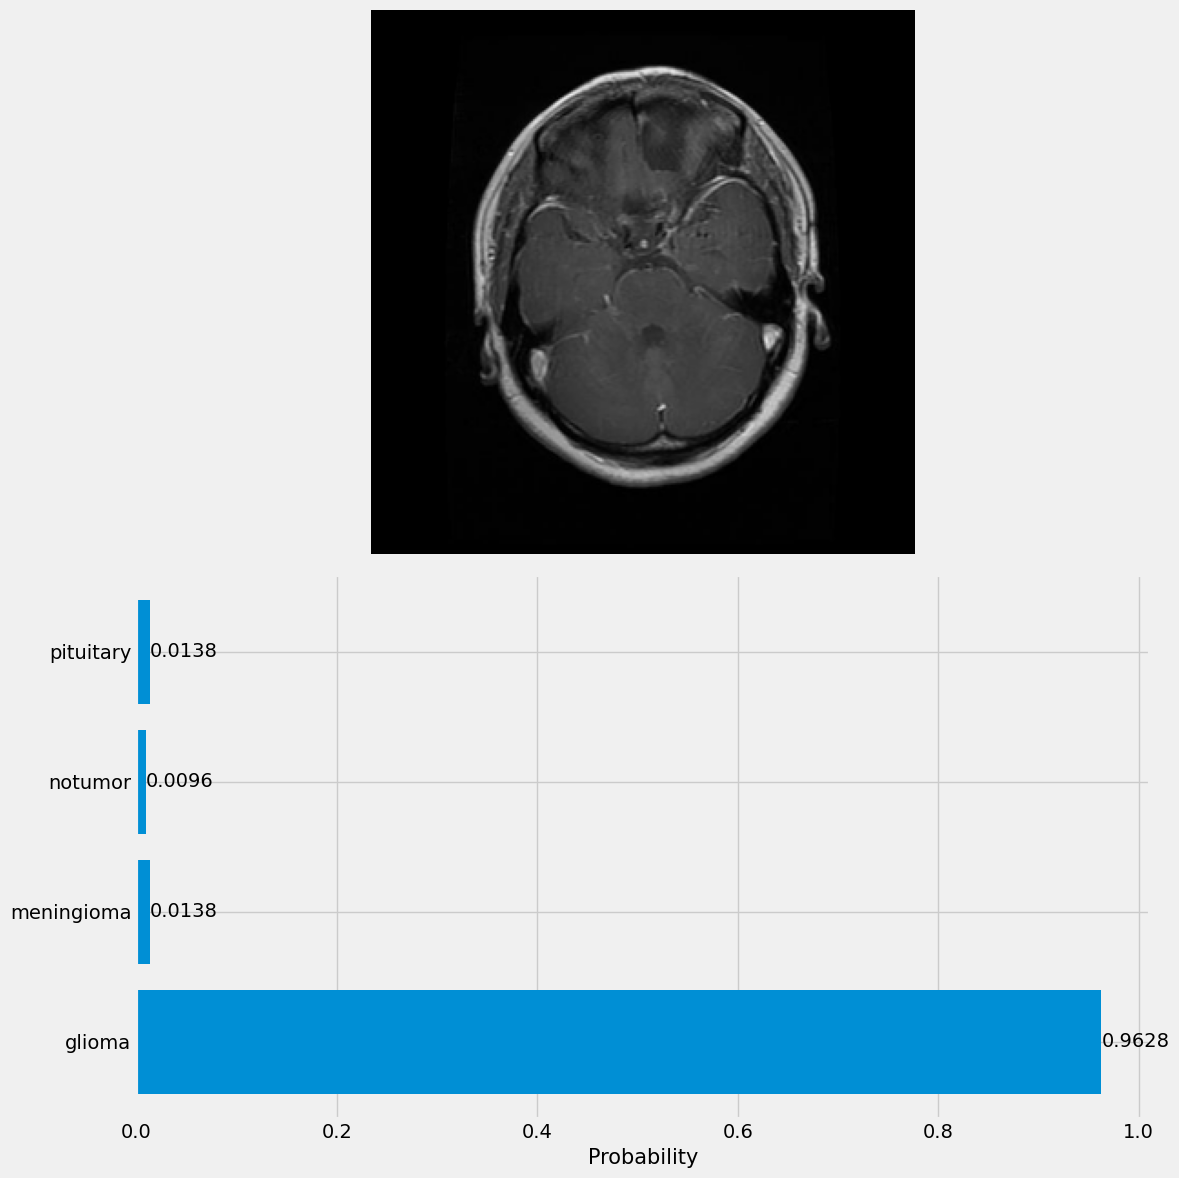

Predicted class: glioma
Probability: 0.9628


('glioma',
 array([0.96284056, 0.01382214, 0.00956413, 0.01377317], dtype=float32))

In [28]:
predict(os.path.join(test_out, 'glioma', random.choice(os.listdir(os.path.join(test_out, 'glioma')))))

### Meningioma

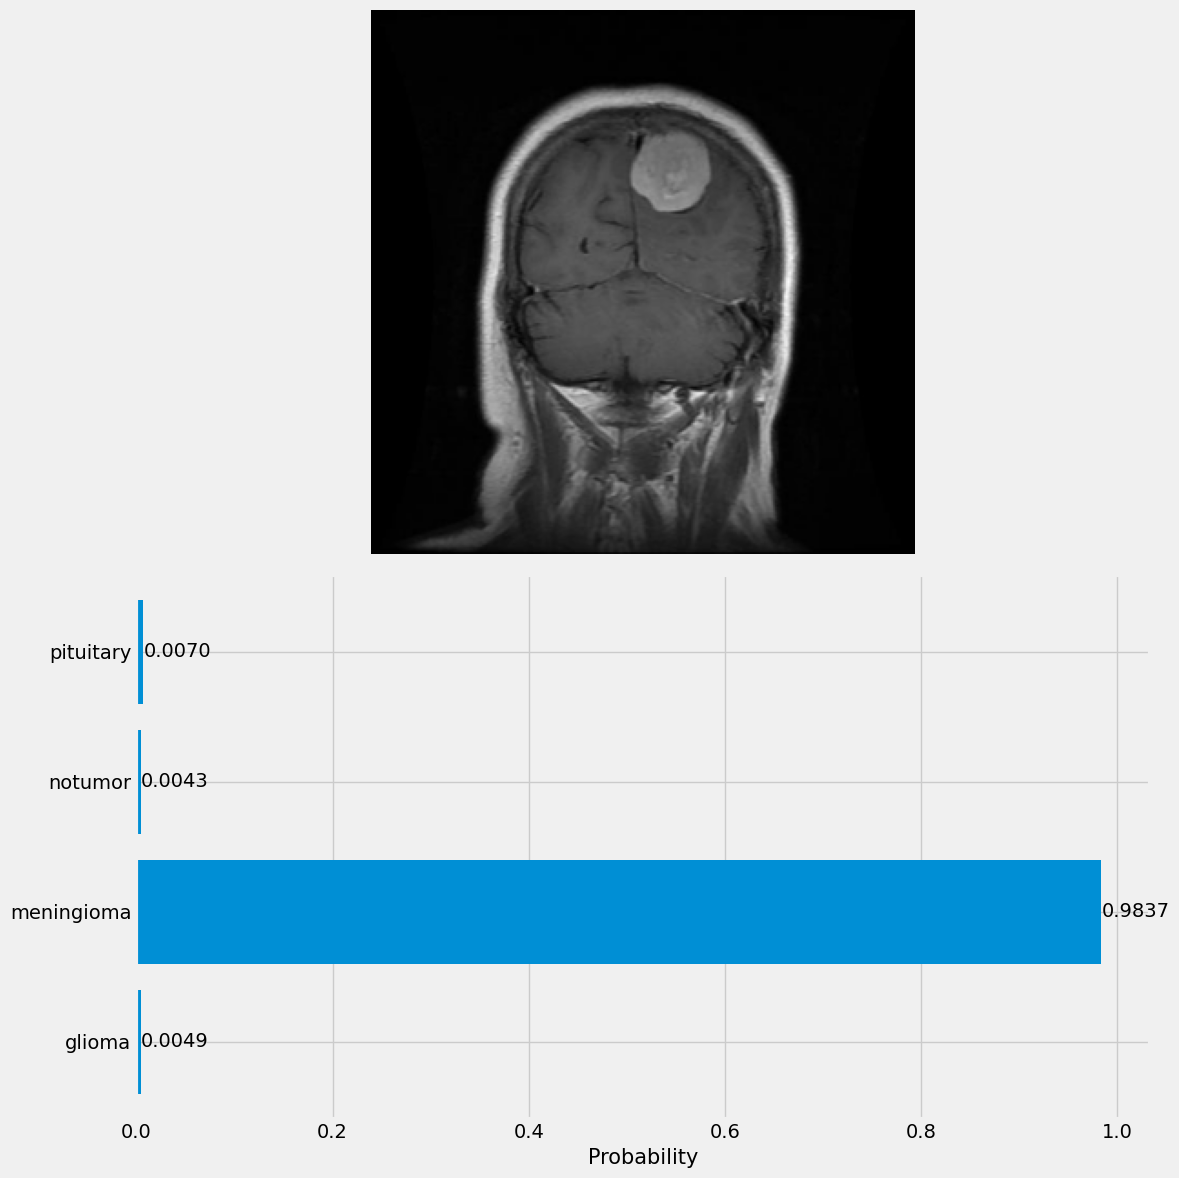

Predicted class: meningioma
Probability: 0.9837


('meningioma',
 array([0.00494742, 0.98367983, 0.00433546, 0.00703726], dtype=float32))

In [29]:
predict(os.path.join(test_out, 'meningioma', random.choice(os.listdir(os.path.join(test_out, 'meningioma')))))

### Pituitary

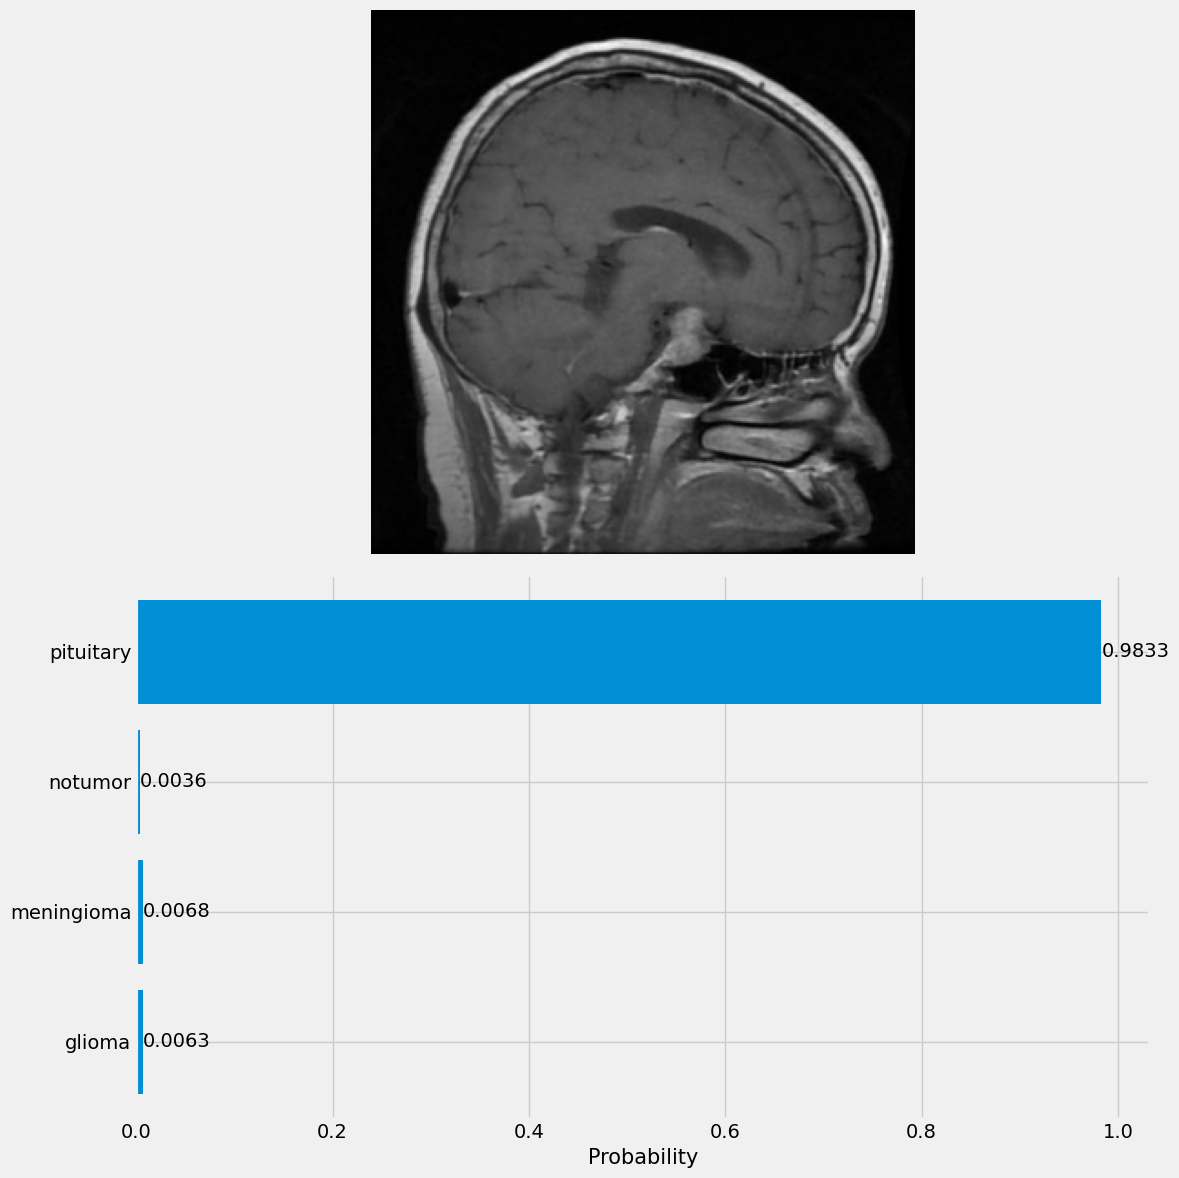

Predicted class: pituitary
Probability: 0.9833


('pituitary',
 array([0.00628627, 0.00676789, 0.00364875, 0.9832971 ], dtype=float32))

In [30]:
predict(os.path.join(test_out, 'pituitary', random.choice(os.listdir(os.path.join(test_out, 'pituitary')))))

### No Tumor

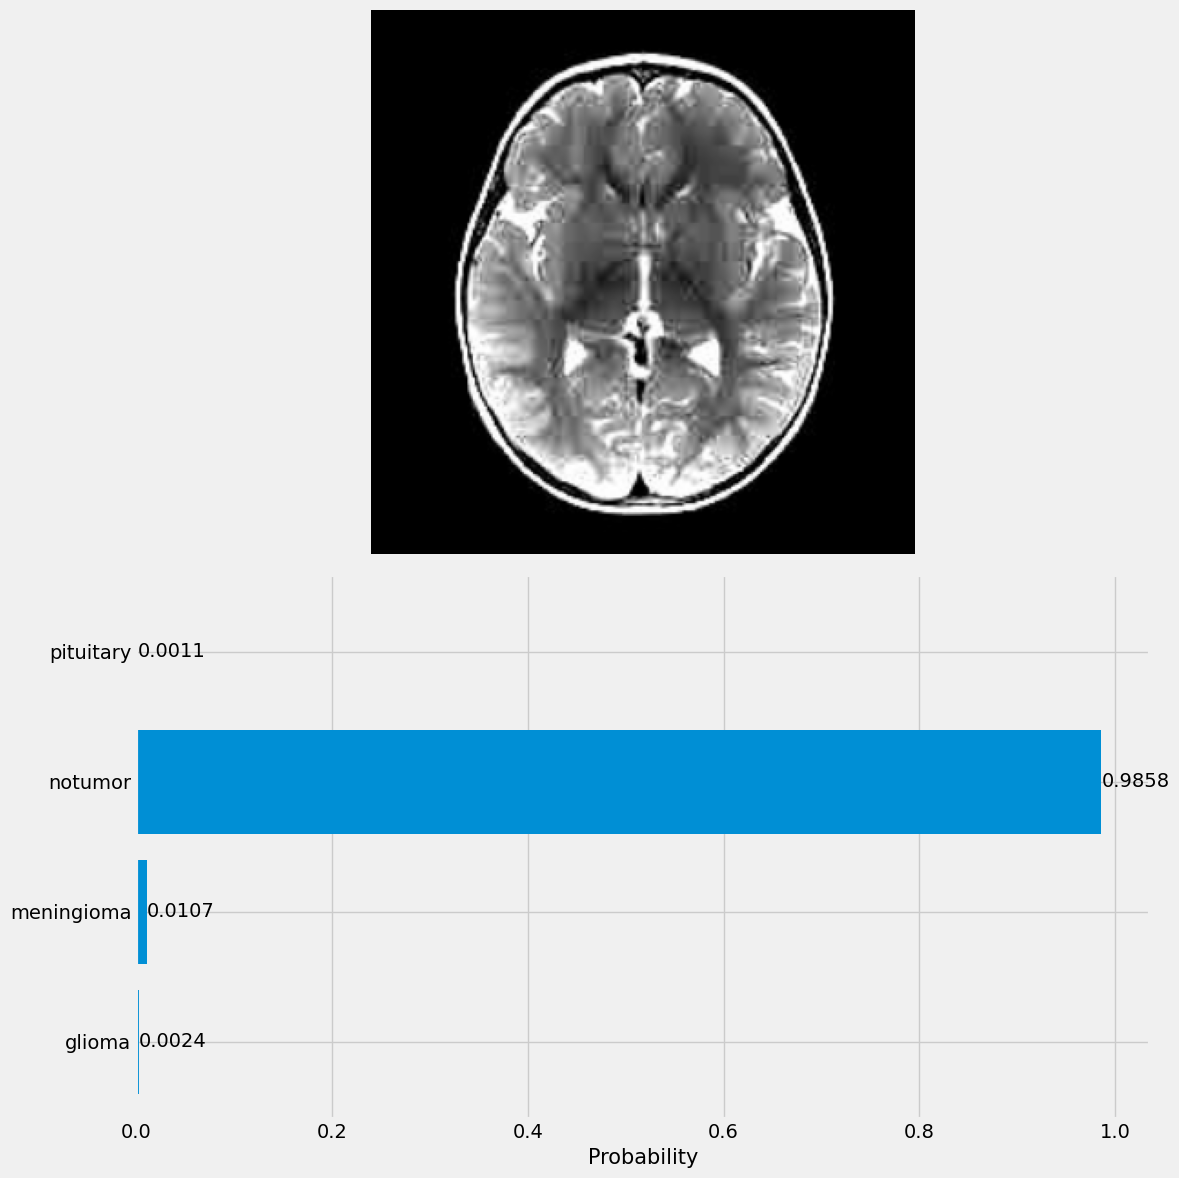

Predicted class: notumor
Probability: 0.9858


('notumor',
 array([0.0023613 , 0.01069094, 0.9858394 , 0.00110837], dtype=float32))

In [31]:
predict(os.path.join(test_out, 'notumor', random.choice(os.listdir(os.path.join(test_out, 'notumor')))))

# 7. Explainability with GradCAM

In [32]:
TARGET_LAYER = "block14_sepconv2_act"
xception = final_model.get_layer("xception")

In [33]:
def build_gradcam_models(final_model, xception, target_layer_name="block14_sepconv2_act"):
    """
    Build the two sub-models needed for Grad-CAM on a model that nests a
    pretrained backbone (Xception) as a single layer, plus a dual-branch
    (GAP + GMP -> Concatenate) classifier head on top.

    Returns
    -------
    feature_model : xception.input -> [target conv layer output, xception output]
        Valid because both tensors live inside xception's OWN functional graph.
    classifier_head : a fresh model (new Input -> ... -> final_model's output)
        that re-applies the actual head layer objects from final_model, so it
        shares their trained weights exactly.
    """
    target_layer = xception.get_layer(target_layer_name)

    feature_model = tf.keras.Model(
        inputs=xception.input,
        outputs=[target_layer.output, xception.output],
        name="gradcam_feature_model"
    )

    # Every layer that comes after the backbone in the outer model, in order
    backbone_idx = final_model.layers.index(xception)
    head_layers = final_model.layers[backbone_idx + 1:]

    head_input = tf.keras.Input(shape=xception.output.shape[1:], name="gradcam_head_input")
    gap_out, gmp_out, x = None, None, None

    for layer in head_layers:
        if isinstance(layer, tf.keras.layers.GlobalAveragePooling2D):
            gap_out = layer(head_input)
        elif isinstance(layer, tf.keras.layers.GlobalMaxPooling2D):
            gmp_out = layer(head_input)
        elif isinstance(layer, tf.keras.layers.Concatenate):
            x = layer([gap_out, gmp_out])
        else:
            x = layer(x, training=False)

    classifier_head = tf.keras.Model(head_input, x, name="gradcam_classifier_head")
    return feature_model, classifier_head


feature_model, classifier_head = build_gradcam_models(final_model, xception, TARGET_LAYER)

# Sanity check: classifier_head(feature_model(x)) should exactly match final_model(x)
for images, labels in test_ds.take(1):
    _sanity_img = images[:1]
    break

_direct = final_model(_sanity_img, training=False)
_pre = final_model.get_layer("xception_preprocess")(_sanity_img, training=False)
_, _feats = feature_model(_pre, training=False)
_via_head = classifier_head(_feats, training=False)

print("Max abs diff between final_model and feature_model+classifier_head:",
      float(tf.reduce_max(tf.abs(_direct - _via_head))))

Max abs diff between final_model and feature_model+classifier_head: 0.0


In [37]:
def make_gradcam_heatmap(
    image,
    final_model,
    feature_model,
    classifier_head,
    class_index=None
):
    """
    Generate Grad-CAM for the nested Xception model.

    image:
        Raw image, shape (299, 299, 3), values in [0, 255].
    final_model:
        Complete trained classification model (used for its
        `xception_preprocess` Rescaling layer).
    feature_model, classifier_head:
        From build_gradcam_models().
    class_index:
        Class to explain. If None, explain the predicted class.
    """
    image = tf.cast(image, tf.float32)

    if len(image.shape) == 3:
        image = tf.expand_dims(image, axis=0)

    # Apply the SAME preprocessing used by the trained model
    preprocess_layer = final_model.get_layer("xception_preprocess")
    image = preprocess_layer(image, training=False)

    with tf.GradientTape() as tape:
        conv_outputs, xception_features = feature_model(image, training=False)
        # Cast up from float16 (mixed_precision policy) for numerically stable heatmap math
        predictions = classifier_head(xception_features, training=False)

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        class_score = predictions[:, class_index]

    # Gradient of the class score w.r.t. the target conv layer's feature maps
    grads = tape.gradient(class_score, conv_outputs)
    grads = tf.cast(grads, tf.float32)
    conv_outputs = tf.cast(conv_outputs, tf.float32)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # Keep only positive contributions
    heatmap = tf.maximum(heatmap, 0)

    # Normalize to [0, 1]
    max_value = tf.reduce_max(heatmap)
    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        tf.zeros_like(heatmap)
    )

    return (
        heatmap.numpy(),
        int(class_index),
        predictions[0].numpy()
    )

In [38]:
def display_gradcam(image, heatmap, alpha=0.4, title=None):
    """
    Display original image and Grad-CAM overlay.
    """

    image = tf.cast(image, tf.float32).numpy()

    # Normalize only for visualization
    image = image - image.min()
    image = image / (image.max() + 1e-8)

    # Resize the heatmap in float (avoids an unnecessary uint8 round-trip
    # before interpolation, which loses precision)
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (image.shape[0], image.shape[1])
    ).numpy().squeeze()
    heatmap_resized = np.clip(heatmap_resized, 0, 1)

    cmap = plt.get_cmap("jet")
    heatmap_color = cmap(heatmap_resized)[..., :3]

    # Overlay
    superimposed = (
        (1 - alpha) * image +
        alpha * heatmap_color
    )
    superimposed = np.clip(superimposed, 0, 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed)
    plt.axis("off")
    plt.title(
        "Grad-CAM" if title is None else title
    )

    plt.tight_layout()
    plt.show()

In [43]:
def load_class_images(class_dir):
    """Load every image in a directory, resized/padded to 299x299, as one batch."""
    filenames = sorted(os.listdir(class_dir))
    paths = [os.path.join(class_dir, f) for f in filenames]
    tensors = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        t = tf.convert_to_tensor(np.asarray(img), dtype=tf.float32)
        t = tf.image.resize_with_pad(t, target_height=299, target_width=299)
        tensors.append(t)
    return paths, tf.stack(tensors)


def find_examples_for_class(true_class_name, class_names, test_out, final_model):
    """
    For a given true class, find one test image the model predicts as each
    possible class (including the true one, i.e. a correctly classified example).

    Returns a dict {predicted_class_name: (image_tensor, probs)}. A predicted
    class is missing from the dict if no test image of `true_class_name` was
    ever classified that way.
    """
    class_dir = os.path.join(test_out, true_class_name)
    paths, batch = load_class_images(class_dir)

    preds = final_model.predict(batch, batch_size=64, verbose=0)
    pred_indices = np.argmax(preds, axis=1)

    examples = {}
    for pred_name in class_names:
        pred_idx = class_names.index(pred_name)
        matches = np.where(pred_indices == pred_idx)[0]
        if len(matches) > 0:
            i = matches[0]
            examples[pred_name] = (batch[i], preds[i])
    return examples


def show_class_gradcams(true_class_name, class_names, test_out, final_model, feature_model, classifier_head):
    """
    Display Grad-CAM for one correctly classified example of `true_class_name`,
    followed by one misclassified example for each of the other classes (when
    the test set contains one).
    """
    examples = find_examples_for_class(true_class_name, class_names, test_out, final_model)

    # Correctly classified example first
    if true_class_name in examples:
        img_tensor, _ = examples[true_class_name]
        heatmap, predicted_index, probs = make_gradcam_heatmap(
            image=img_tensor, final_model=final_model,
            feature_model=feature_model, classifier_head=classifier_head
        )
        display_gradcam(
            img_tensor, heatmap,
            title=f"True: {true_class_name} | Predicted: {class_names[predicted_index]} ({probs[predicted_index]*100:.1f}%) - Correct"
        )
    else:
        print(f"No correctly classified '{true_class_name}' example found in the test set.")

    # One misclassified example per wrong class
    for wrong_class in class_names:
        if wrong_class == true_class_name:
            continue
        if wrong_class in examples:
            img_tensor, _ = examples[wrong_class]
            heatmap, predicted_index, probs = make_gradcam_heatmap(
                image=img_tensor, final_model=final_model,
                feature_model=feature_model, classifier_head=classifier_head
            )
            display_gradcam(
                img_tensor, heatmap,
                title=f"True: {true_class_name} | Predicted: {class_names[predicted_index]} ({probs[predicted_index]*100:.1f}%) - Misclassified"
            )
        else:
            print(f"No '{true_class_name}' example misclassified as '{wrong_class}' found in the test set.")

### Glioma

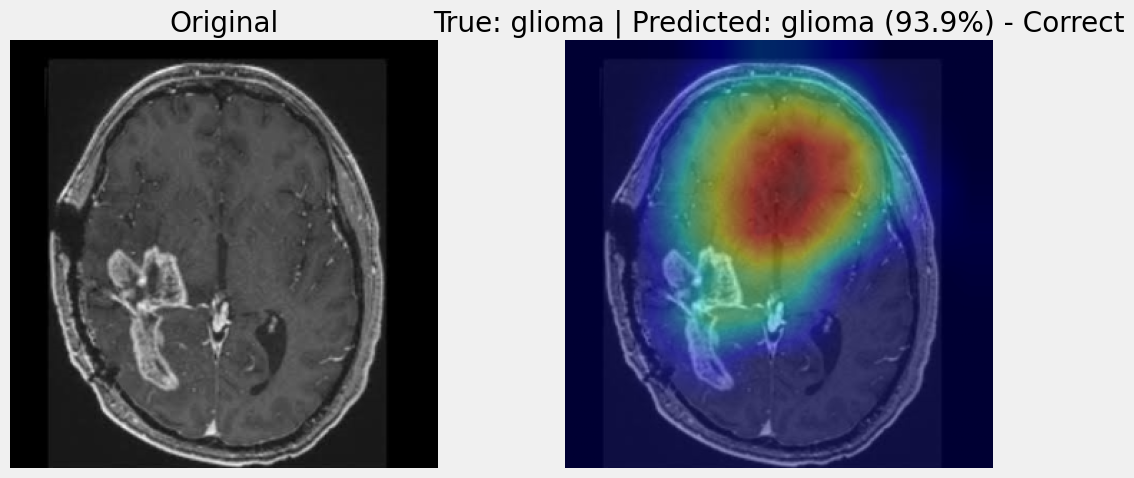

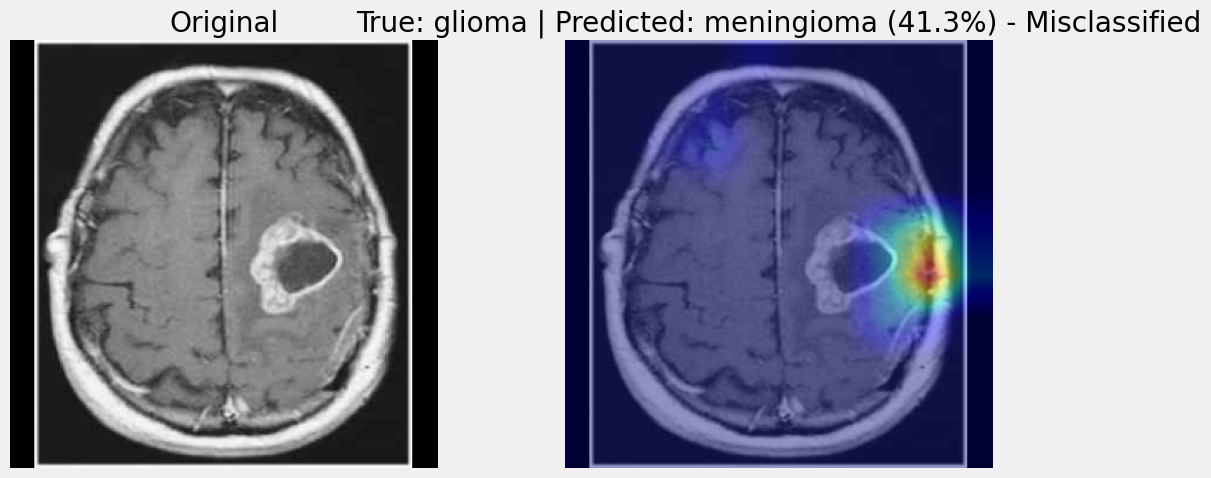

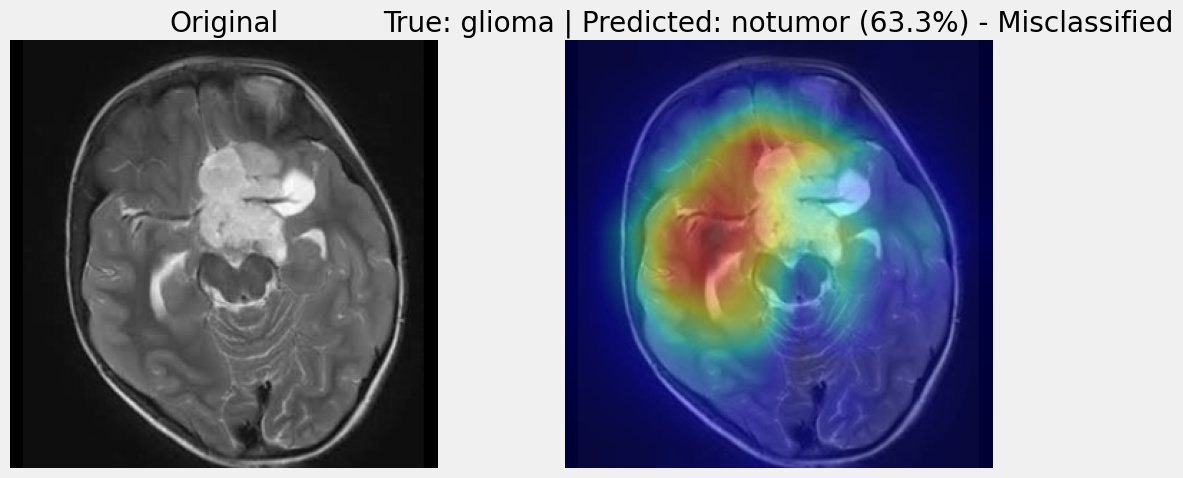

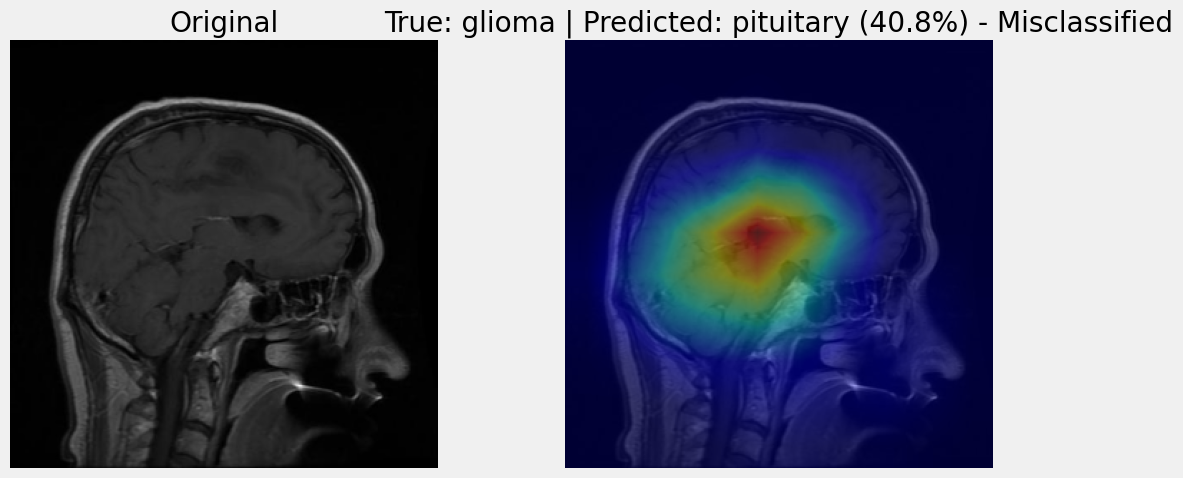

In [44]:
show_class_gradcams("glioma", class_names, test_out, final_model, feature_model, classifier_head)

### Meningioma

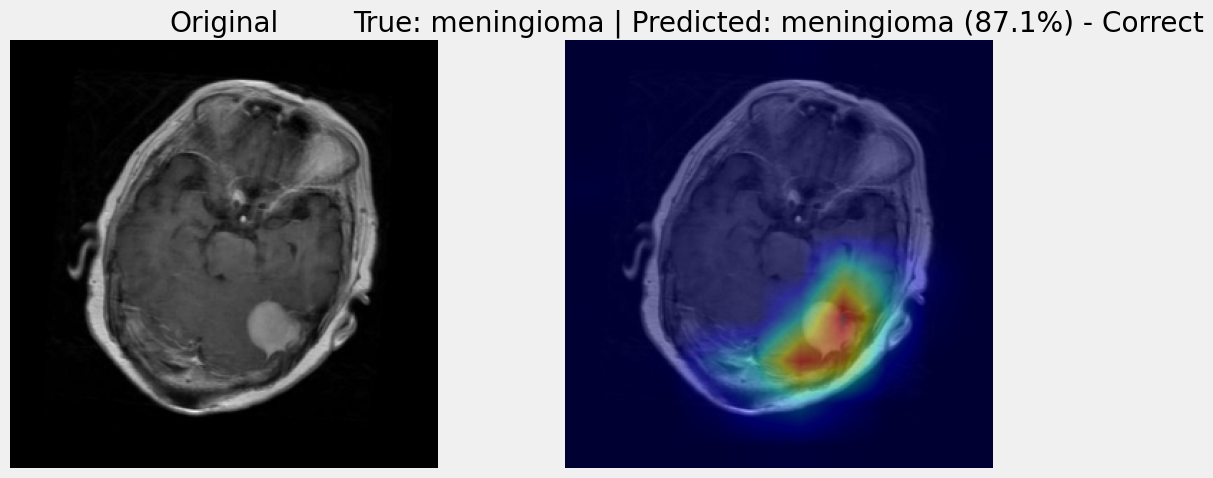

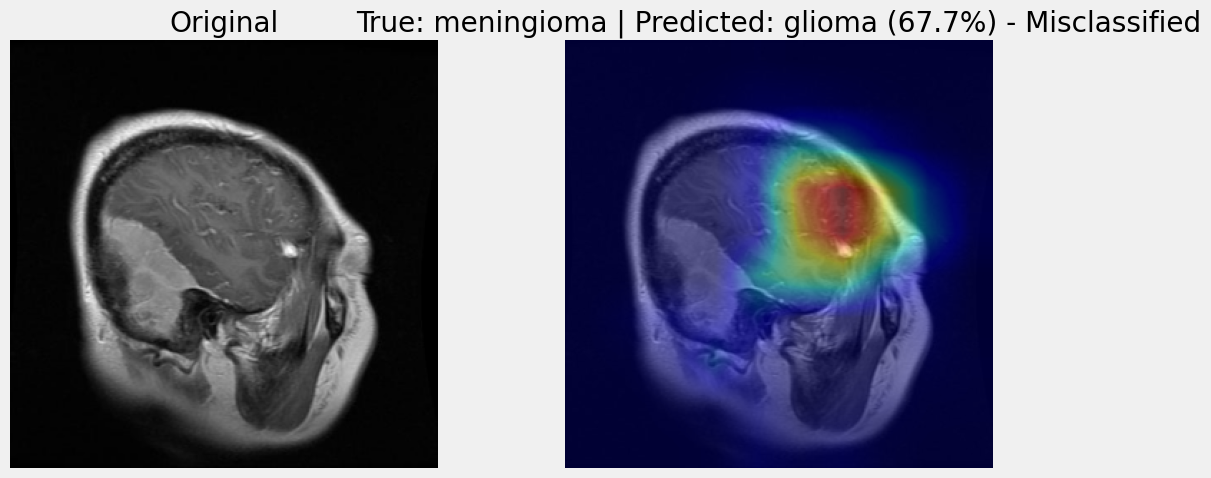

No 'meningioma' example misclassified as 'notumor' found in the test set.


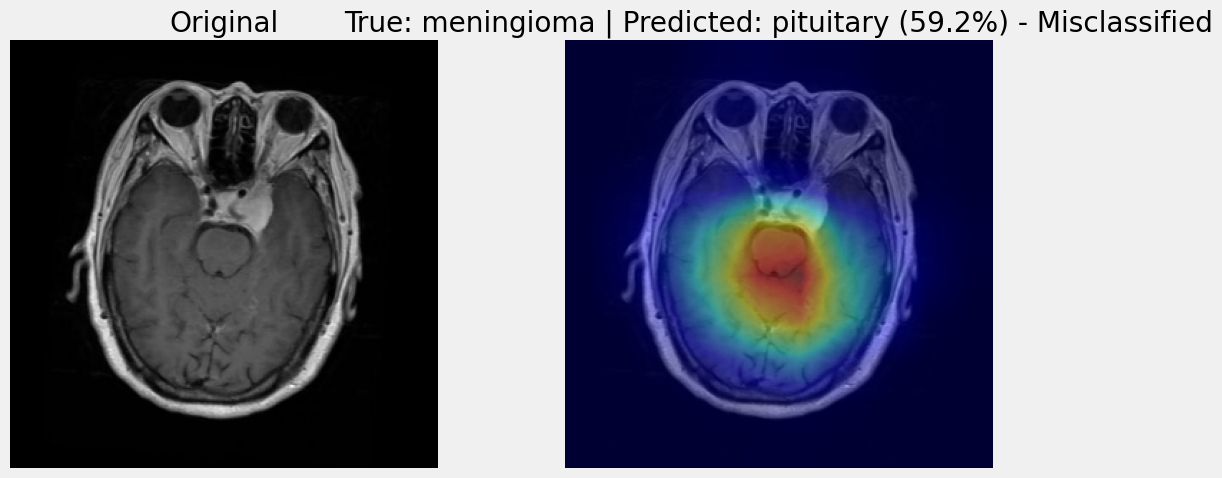

In [45]:
show_class_gradcams("meningioma", class_names, test_out, final_model, feature_model, classifier_head)

### Pituitary

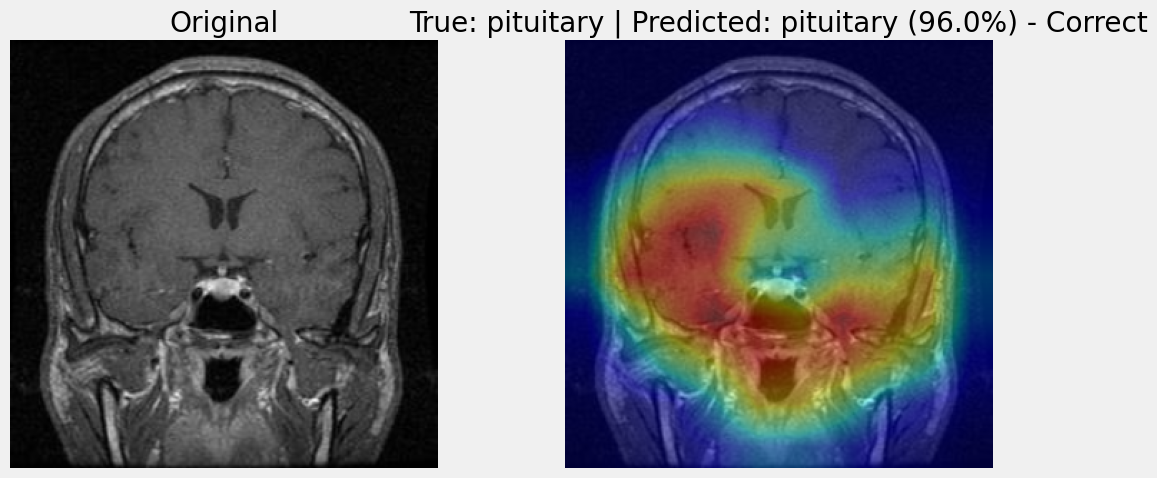

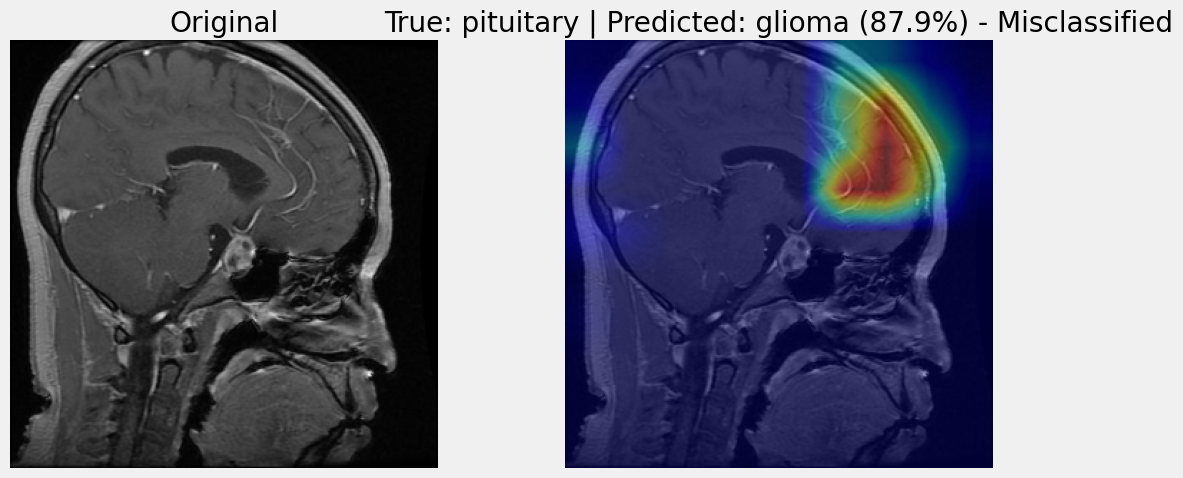

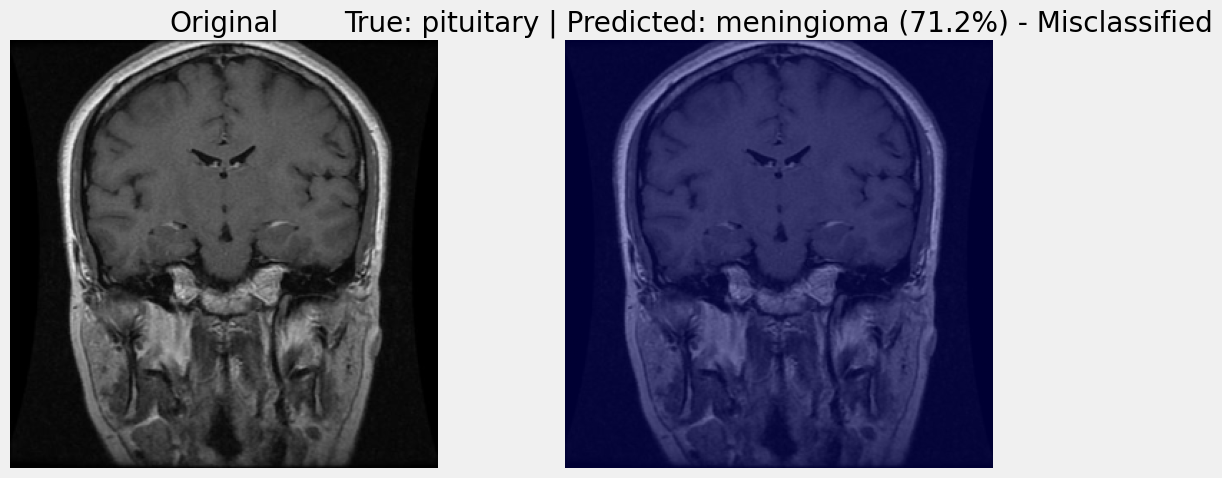

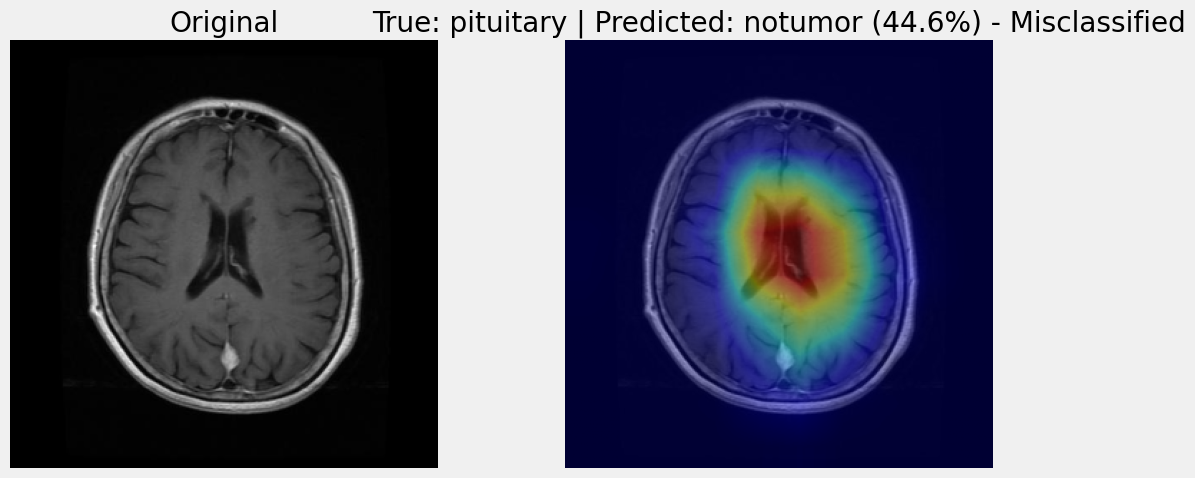

In [46]:
show_class_gradcams("pituitary", class_names, test_out, final_model, feature_model, classifier_head)

### No Tumor

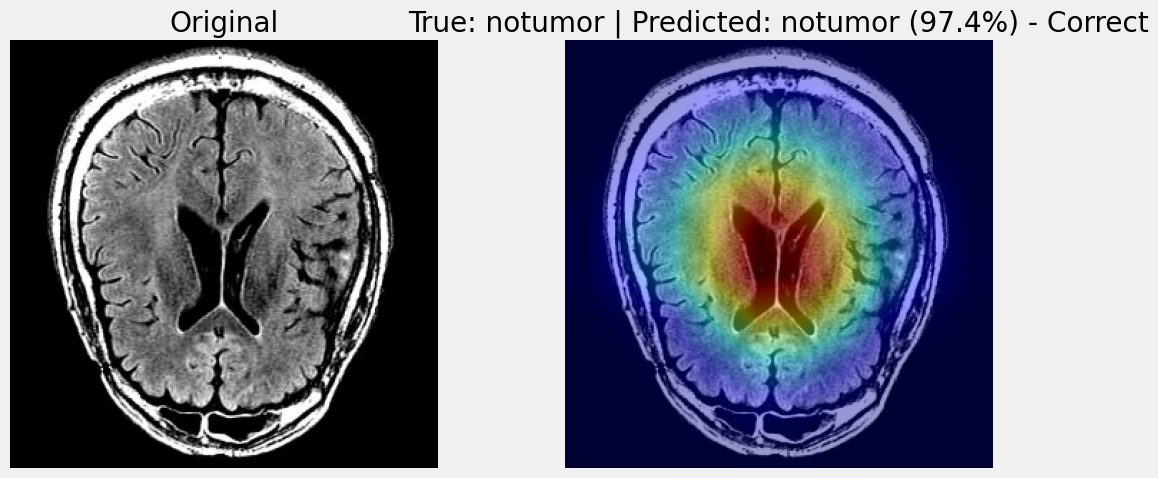

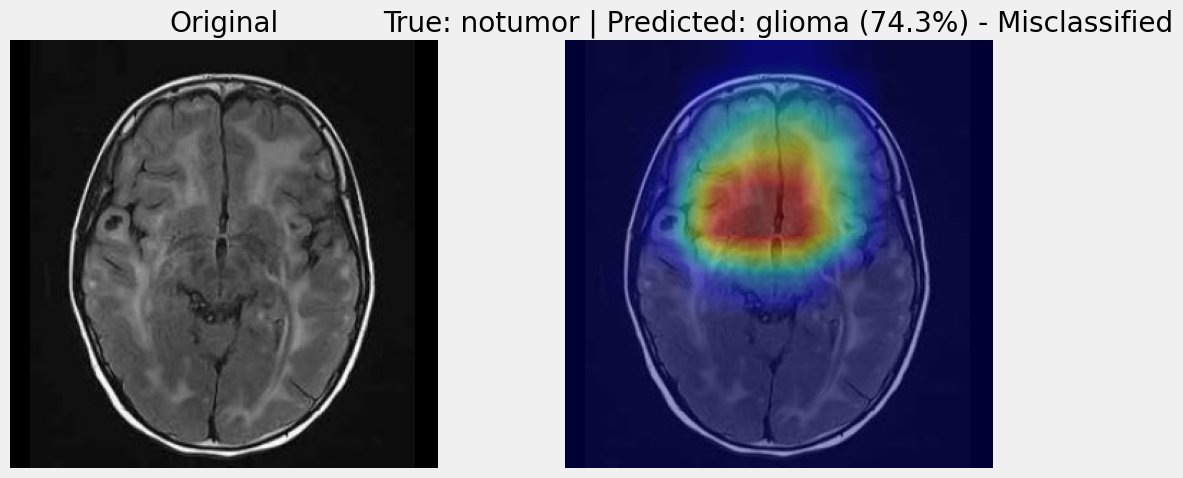

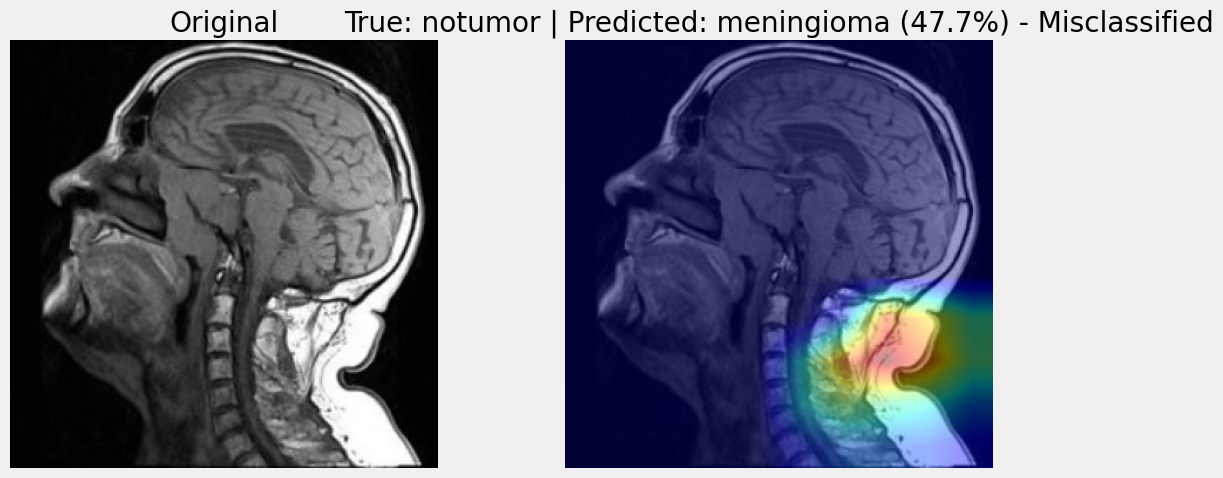

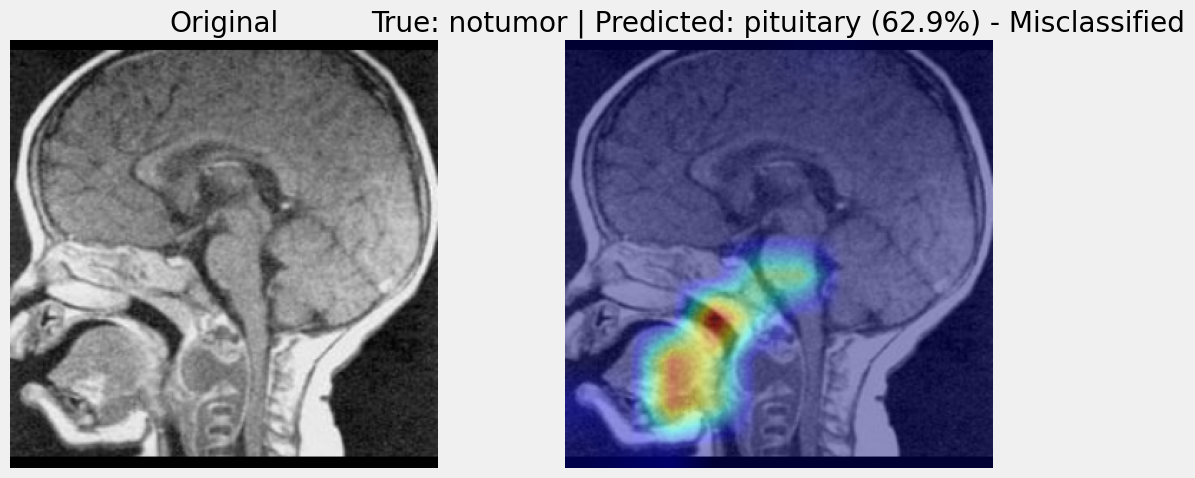

In [47]:
show_class_gradcams("notumor", class_names, test_out, final_model, feature_model, classifier_head)